# TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

## Improving Customer Satisfaction through Automated Review Sentiment Analysis

**Objective:** Build an NLP system that classifies Amazon customer reviews as **Positive** or **Negative**.

### Business Goals
- Monitor product performance through customer feedback.
- Identify increases in negative sentiment.
- Help customer/product teams respond to complaints faster.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from wordcloud import WordCloud
pd.set_option('display.max_colwidth', 120)

## 1. Load the Dataset

The supplied dataset contains two columns: label (`pos`/`neg`) and `review` (customer text).

In [2]:
DATA_PATH = 'amazonreviews.tsv'
df = pd.read_csv(DATA_PATH, sep='\t')
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (10000, 2)


,label,review
0,pos,Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would re...
1,pos,The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' a...
2,pos,"Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (..."
3,pos,Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played this game and most of...
4,pos,"Remember, Pull Your Jaw Off The Floor After Hearing it: If you've played the game, you know how divine the music is!..."


## 2. Data Quality Check

In [3]:
print('Data types:')
display(df.dtypes)
print('\nMissing values:')
display(df.isnull().sum())
print('\nDuplicate rows:')
print(df.duplicated().sum())
print('\nSentiment distribution:')
display(df['label'].value_counts())

Data types:


label     object
review    object
dtype: object


Missing values:


label     0
review    0
dtype: int64


Duplicate rows:
0

Sentiment distribution:


label
neg    5097
pos    4903
Name: count, dtype: int64

### Data Quality Findings

The supplied dataset contains **10,000 reviews**, **no missing values**, and **no duplicate rows**. There are **5,097 negative reviews** and **4,903 positive reviews**, so the classes are reasonably balanced.

In [4]:
before=len(df)
df=df.dropna(subset=['review','label']).drop_duplicates().reset_index(drop=True)
print('Rows before cleaning:', before)
print('Rows after cleaning :', len(df))

Rows before cleaning: 10000
Rows after cleaning : 10000


## 3. Exploratory Data Analysis

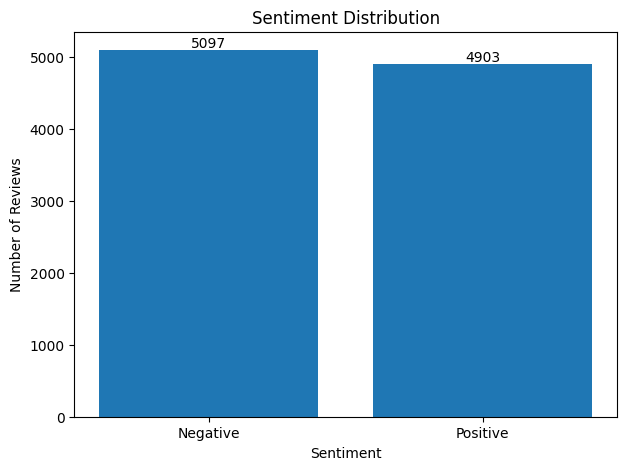

In [5]:
counts=df['label'].value_counts().reindex(['neg','pos'])
plt.figure(figsize=(7,5))
bars=plt.bar(['Negative','Positive'], counts.values)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, value, str(value), ha='center', va='bottom')
plt.show()

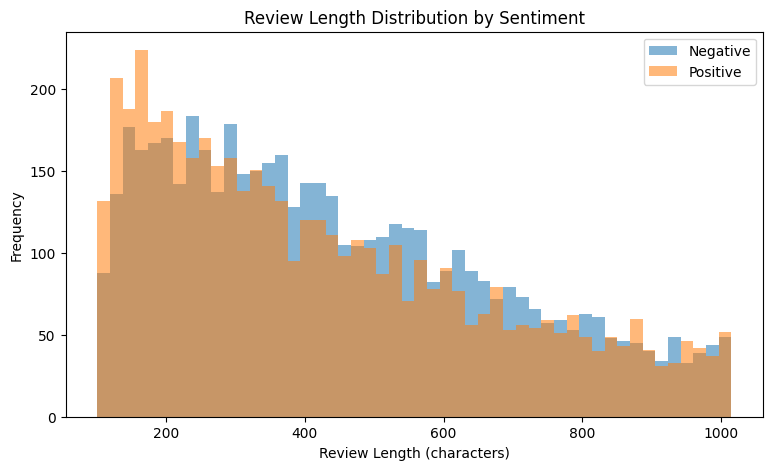

,count,mean,median,min,max
label,,,,,
neg,5097,449.159309,407.0,101,1015
pos,4903,427.817459,370.0,101,1015


In [6]:
df['review_length']=df['review'].str.len()
plt.figure(figsize=(9,5))
plt.hist(df.loc[df['label']=='neg','review_length'],bins=50,alpha=0.55,label='Negative')
plt.hist(df.loc[df['label']=='pos','review_length'],bins=50,alpha=0.55,label='Positive')
plt.legend()
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Review Length (characters)')
plt.ylabel('Frequency')
plt.show()
display(df.groupby('label')['review_length'].agg(['count','mean','median','min','max']))

## 4. Text Preprocessing

Text is lowercased, HTML line breaks are removed, unnecessary characters are removed, and tokens are created. Important negation words such as **not** and **no** are retained because phrases such as `not good` and `not worth` are important for sentiment.

In [7]:
stop_words=set("""a an the and are as at be by for from has have he her his
i if in into is it its me my of on or our she that their
there they this to was we were what when which who will with
you your""".split())

def clean_text(text):
    text=str(text).lower()
    text=re.sub(r'<br\s*/?>',' ',text)
    text=re.sub(r"[^a-z\s']",' ',text)
    tokens=re.findall(r"[a-z']+",text)
    tokens=[w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_review']=df['review'].apply(clean_text)
display(df[['review','clean_review']].head())

,review,clean_review
0,Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would re...,stuning even non gamer sound track beautiful paints senery mind so well would recomend even people hate vid game mus...
1,The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' a...,best soundtrack ever anything i'm reading lot reviews saying best 'game soundtrack' figured i'd write review disagre...
2,"Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (...",amazing soundtrack favorite music all time hands down intense sadness prisoners fate means all more you've played ga...
3,Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played this game and most of...,excellent soundtrack truly like soundtrack enjoy video game music played game most music here enjoy it's truly relax...
4,"Remember, Pull Your Jaw Off The Floor After Hearing it: If you've played the game, you know how divine the music is!...",remember pull jaw off floor after hearing you've played game know how divine music every single song tells story gam...


In [8]:
df['label_num']=df['label'].map({'neg':0,'pos':1})
display(df[['label','label_num']].head())

,label,label_num
0,pos,1
1,pos,1
2,pos,1
3,pos,1
4,pos,1


## 5. Most Common Words

In [9]:
def get_top_words(text_series,n=20):
    words=[]
    for text in text_series: words.extend(text.split())
    return Counter(words).most_common(n)

positive_words=get_top_words(df.loc[df['label']=='pos','clean_review'])
negative_words=get_top_words(df.loc[df['label']=='neg','clean_review'])
print('Top words in positive reviews:')
print(positive_words)
print('\nTop words in negative reviews:')
print(negative_words)

Top words in positive reviews:
[('book', 3376), ('but', 2610), ('great', 2135), ('not', 1962), ('one', 1895), ('good', 1666), ('very', 1616), ('read', 1604), ('all', 1588), ('so', 1578), ('like', 1290), ('about', 1209), ('movie', 1116), ('just', 1036), ('more', 1034), ('out', 1024), ("it's", 967), ('can', 961), ('would', 950), ('well', 944)]

Top words in negative reviews:
[('not', 4449), ('but', 3372), ('book', 3258), ('one', 2092), ('so', 1778), ('all', 1696), ('like', 1568), ('just', 1525), ('movie', 1514), ('would', 1446), ('very', 1427), ('about', 1347), ('no', 1258), ('read', 1222), ('out', 1206), ('had', 1176), ('good', 1160), ('get', 1151), ("don't", 1131), ('only', 1125)]


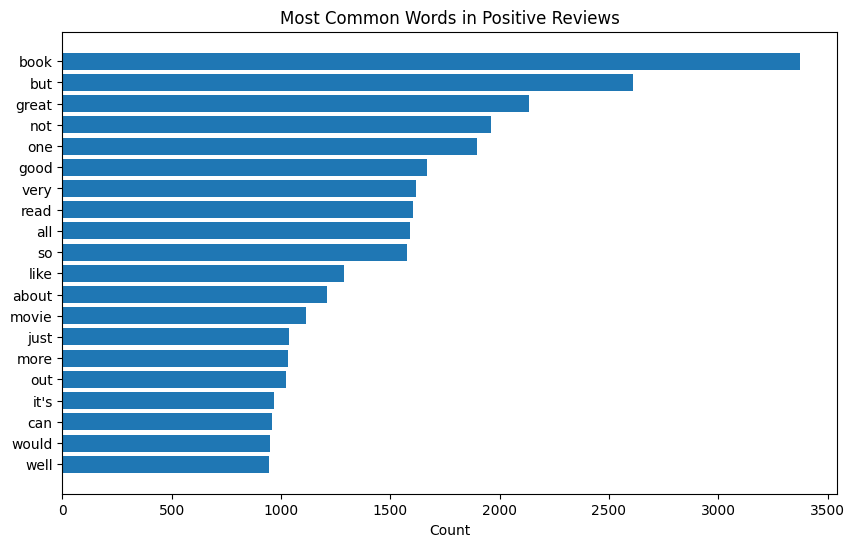

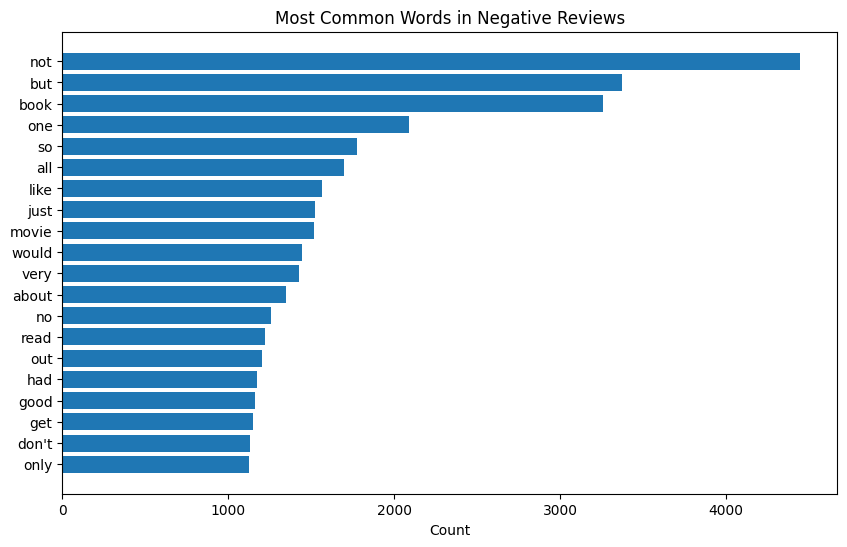

In [10]:
pos_words=pd.DataFrame(positive_words,columns=['word','count'])
neg_words=pd.DataFrame(negative_words,columns=['word','count'])
plt.figure(figsize=(10,6)); plt.barh(pos_words['word'][::-1],pos_words['count'][::-1]); plt.title('Most Common Words in Positive Reviews'); plt.xlabel('Count'); plt.show()
plt.figure(figsize=(10,6)); plt.barh(neg_words['word'][::-1],neg_words['count'][::-1]); plt.title('Most Common Words in Negative Reviews'); plt.xlabel('Count'); plt.show()

## 6. Word Clouds

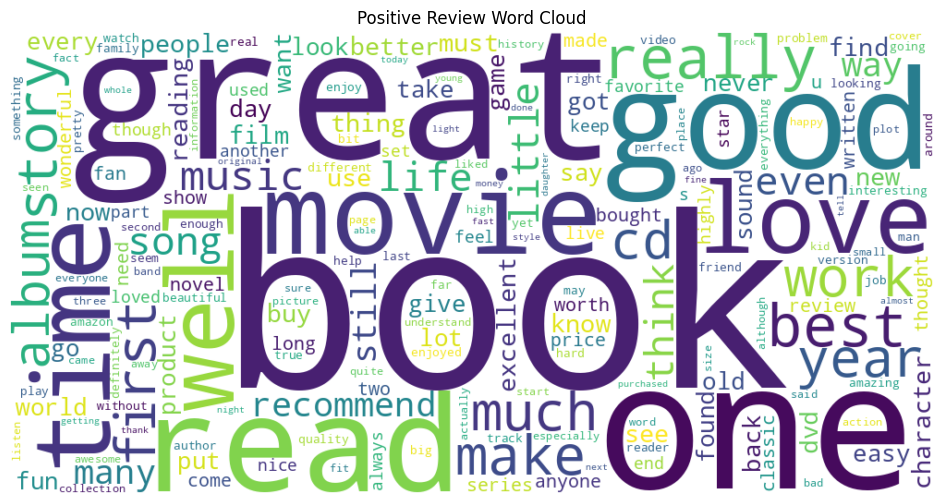

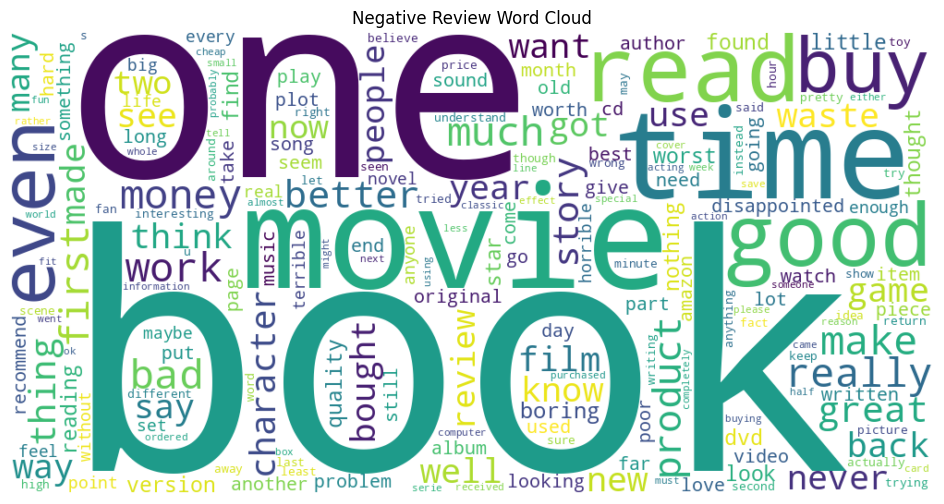

In [11]:
positive_text=' '.join(df.loc[df['label']=='pos','clean_review'])
negative_text=' '.join(df.loc[df['label']=='neg','clean_review'])
positive_wc=WordCloud(width=1000,height=500,background_color='white',collocations=False,random_state=42).generate(positive_text)
negative_wc=WordCloud(width=1000,height=500,background_color='white',collocations=False,random_state=42).generate(negative_text)
plt.figure(figsize=(12,6)); plt.imshow(positive_wc,interpolation='bilinear'); plt.axis('off'); plt.title('Positive Review Word Cloud'); plt.show()
plt.figure(figsize=(12,6)); plt.imshow(negative_wc,interpolation='bilinear'); plt.axis('off'); plt.title('Negative Review Word Cloud'); plt.show()

## 7. Train-Test Split

An **80/20 stratified split** is used so the class distribution is preserved.

In [12]:
X=df['clean_review']; y=df['label_num']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print('Training samples:',len(X_train))
print('Testing samples :',len(X_test))

Training samples: 8000
Testing samples : 2000


## 8. Model Development

Two classifiers are evaluated: **TF-IDF + Logistic Regression** and **TF-IDF + Linear SVM**. Both use unigrams and bigrams.

In [13]:
logistic_model=Pipeline([('tfidf',TfidfVectorizer(ngram_range=(1,2),min_df=2,max_df=0.95,sublinear_tf=True)),('classifier',LogisticRegression(max_iter=2000,C=2))])
logistic_model.fit(X_train,y_train)
logistic_pred=logistic_model.predict(X_test)
logistic_accuracy=accuracy_score(y_test,logistic_pred)
logistic_f1=f1_score(y_test,logistic_pred)
print('Logistic Regression Accuracy:',logistic_accuracy)
print('Logistic Regression F1       :',logistic_f1)

Logistic Regression Accuracy: 0.87
Logistic Regression F1       : 0.8670756646216768


In [14]:
svm_model=Pipeline([('tfidf',TfidfVectorizer(ngram_range=(1,2),min_df=2,max_df=0.95,sublinear_tf=True)),('classifier',LinearSVC(C=1.5))])
svm_model.fit(X_train,y_train)
svm_pred=svm_model.predict(X_test)
svm_accuracy=accuracy_score(y_test,svm_pred)
svm_precision=precision_score(y_test,svm_pred)
svm_recall=recall_score(y_test,svm_pred)
svm_f1=f1_score(y_test,svm_pred)
print('Linear SVM Results')
print('Accuracy :',svm_accuracy)
print('Precision:',svm_precision)
print('Recall   :',svm_recall)
print('F1 Score :',svm_f1)
print('\nClassification Report:')
print(classification_report(y_test,svm_pred,target_names=['Negative','Positive']))

Linear SVM Results
Accuracy : 0.8745
Precision: 0.8701825557809331
Recall   : 0.8746177370030581
F1 Score : 0.8723945094051856

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88      1019
    Positive       0.87      0.87      0.87       981

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



## 9. Model Comparison

,Model,Accuracy,F1 Score
0,TF-IDF + Logistic Regression,0.8700,0.867076
1,TF-IDF + Linear SVM,0.8745,0.872395


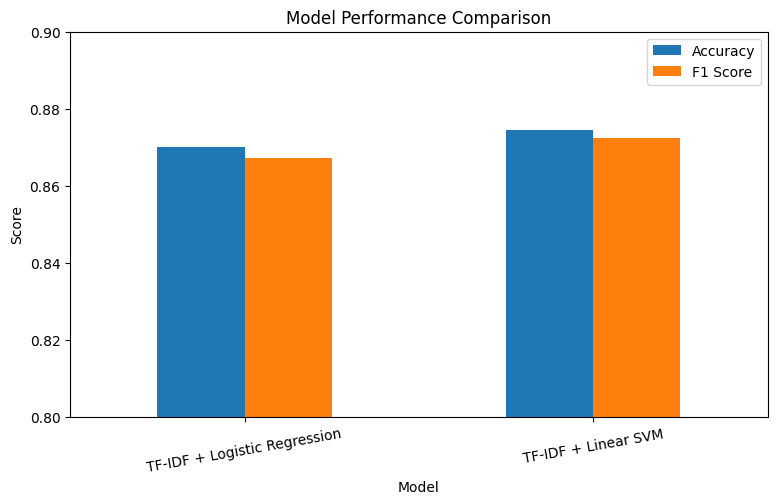

In [15]:
comparison=pd.DataFrame({'Model':['TF-IDF + Logistic Regression','TF-IDF + Linear SVM'],'Accuracy':[logistic_accuracy,svm_accuracy],'F1 Score':[logistic_f1,svm_f1]})
display(comparison)
comparison_melted=comparison.melt(id_vars='Model',value_vars=['Accuracy','F1 Score'],var_name='Metric',value_name='Score')
pivot=comparison.set_index('Model')[['Accuracy','F1 Score']]
pivot.plot(kind='bar',figsize=(9,5))
plt.ylim(0.80,0.90)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=10)
plt.legend()
plt.show()

## 10. Confusion Matrix

Confusion Matrix:
[[891 128]
 [123 858]]


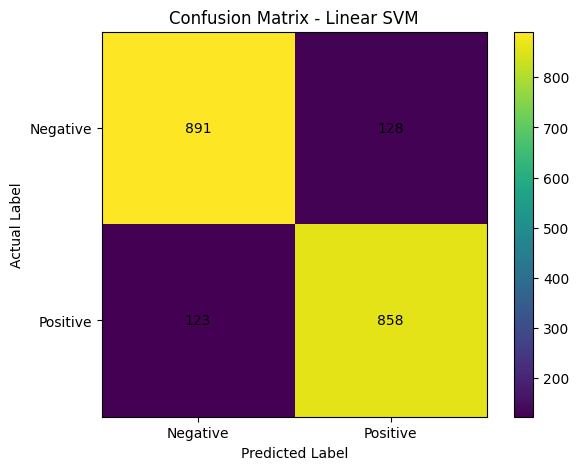

In [16]:
cm=confusion_matrix(y_test,svm_pred)
print('Confusion Matrix:')
print(cm)
plt.figure(figsize=(7,5))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix - Linear SVM')
plt.colorbar()
plt.xticks([0,1],['Negative','Positive'])
plt.yticks([0,1],['Negative','Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha='center',va='center')
plt.show()

## 11. Five-Fold Cross-Validation

Stratified 5-fold cross-validation is used on the training data to assess stability.

In [17]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(svm_model,X_train,y_train,cv=cv,scoring='f1')
print('Cross-validation F1 scores:')
for i,score in enumerate(cv_scores,1): print(f'Fold {i}: {score:.4f}')
print('\nMean CV F1 Score:',cv_scores.mean())
print('Standard Deviation:',cv_scores.std())

Cross-validation F1 scores:
Fold 1: 0.8774
Fold 2: 0.8862
Fold 3: 0.8940
Fold 4: 0.8862
Fold 5: 0.8868

Mean CV F1 Score: 0.8861052566179541
Standard Deviation: 0.0052873942973182455


## 12. Important Sentiment Features

In [18]:
tfidf=svm_model.named_steps['tfidf']; classifier=svm_model.named_steps['classifier']
feature_names=tfidf.get_feature_names_out(); coefficients=classifier.coef_[0]
positive_indices=np.argsort(coefficients)[-20:][::-1]; negative_indices=np.argsort(coefficients)[:20]
print('Strong Positive Features:'); print(feature_names[positive_indices])
print('\nStrong Negative Features:'); print(feature_names[negative_indices])

Strong Positive Features:
['great' 'excellent' 'perfect' 'love' 'best' 'good' 'wonderful' 'must'
 'amazing' 'favorite' 'pleased' 'loves' 'awesome' 'one best' 'easy'
 'beautiful' 'fun' 'well' 'fantastic' 'solid']

Strong Negative Features:
['not' 'boring' 'poor' 'worst' 'bad' 'disappointed' 'waste'
 'disappointing' 'not worth' 'not good' 'horrible' 'terrible'
 'not recommend' 'nothing' 'disappointment' 'no' 'don' 'unfortunately'
 'idea' 'return']


## 13. Sample Predictions

In [19]:
custom_reviews=['This product is excellent and I absolutely love it.','The product is terrible and completely disappointing.','Amazing quality and very easy to use.','Waste of money. I would not recommend this product.']
custom_clean=[clean_text(review) for review in custom_reviews]
predictions=svm_model.predict(custom_clean)
for review,prediction in zip(custom_reviews,predictions):
    sentiment='Positive' if prediction==1 else 'Negative'
    print(f'Review: {review}')
    print(f'Prediction: {sentiment}\n')

Review: This product is excellent and I absolutely love it.
Prediction: Positive

Review: The product is terrible and completely disappointing.
Prediction: Negative

Review: Amazing quality and very easy to use.
Prediction: Positive

Review: Waste of money. I would not recommend this product.
Prediction: Negative



## 14. Final Findings

The Linear SVM is selected as the final model because it slightly outperformed Logistic Regression on the held-out test set. The final pipeline combines sentiment-aware preprocessing, TF-IDF features, unigrams and bigrams, Linear SVM classification, stratified splitting, cross-validation, and multiple evaluation metrics. The approach is suitable as a practical baseline for automated review monitoring and can later be extended into a product-level sentiment dashboard.